# Tabulated proton and neutron densities

This notebook demonstrates the packaged density tables exposed through `jitr.utils.density`. The tables provide proton and neutron densities for specific `(A, Z)` targets in two density models, which can be interpolated onto any radial grid.

The densitiea are predictions of the deformed density distribution obtained within the Hartree-Fock-Bogoliubov method with the D1S Gogny effective interaction from 
- J. Decharge and D. Gogny, Phys. Rev. C21, 1568 (1980),
- S. Hilaire and M. Girod, Eur. Phys. J. A33, 237 (2007),

and within the bskg3 Skyrme force:
-  S. Goriely, M. Samyn, and J.M. Pearson, Phys. Rev. C75, 064312 (2007),
-  G. Audi, A.H. Wapstra, and C. Thibault, Nucl. Phys. A729, 337 (2003),
-   I. Angeli, At. Data Nucl. Data Tables 87, 185 (2004).

The tables are copied from the [TALYS code](https://github.com/arjankoning1/talys/tree/main/structure/optical/jlm).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from jitr.utils import density
from jitr.utils.density import TwoParameterFermiDensity

In [2]:
density.density_models()

['bskg3', 'd1m']

In [3]:
density.density_models(), density.density_targets(model="d1m", Z=8)

(['bskg3', 'd1m'],
 [(12, 8),
  (13, 8),
  (14, 8),
  (15, 8),
  (16, 8),
  (17, 8),
  (18, 8),
  (19, 8),
  (20, 8),
  (21, 8),
  (22, 8),
  (23, 8),
  (24, 8),
  (25, 8),
  (26, 8),
  (27, 8),
  (28, 8),
  (29, 8),
  (30, 8)])

In [4]:
A, Z = 16, 8
r = np.linspace(0.0, 10.0, 400)

rho_p_d1m, rho_n_d1m = density.densities(A, Z, r, model="d1m")
rho_p_bskg3, rho_n_bskg3 = density.densities(A, Z, r, model="bskg3")

table = density.density_table(A, Z, model="d1m")
proton_number = 4.0 * np.pi * np.trapezoid(
    table.radial_grid**2 * table.proton_density_grid,
    table.radial_grid,
)
neutron_number = 4.0 * np.pi * np.trapezoid(
    table.radial_grid**2 * table.neutron_density_grid,
    table.radial_grid,
)

assert np.isclose(proton_number, Z, rtol=1e-4)
assert np.isclose(neutron_number, A - Z, rtol=1e-4)

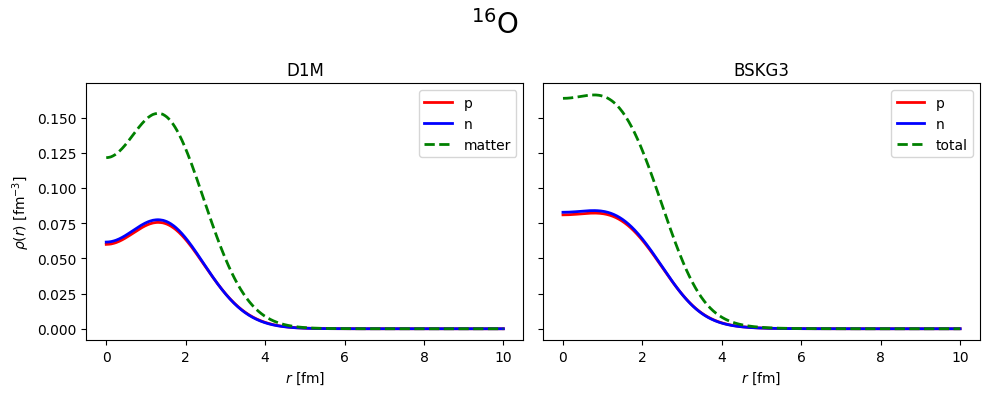

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].plot(r, rho_p_d1m, color='r', label="p", linewidth=2)
axes[0].plot(r, rho_n_d1m, color='b', label="n", linewidth=2)
axes[0].plot(r, rho_p_d1m + rho_n_d1m, color='g', label="matter", linestyle="--", linewidth=2)
axes[0].set_title("D1M")
axes[0].set_xlabel(r"$r$ [fm]")
axes[0].set_ylabel(r"$\rho(r)$ [fm$^{-3}$]")
axes[0].legend()

axes[1].plot(r, rho_p_bskg3, color='r', label="p", linewidth=2)
axes[1].plot(r, rho_n_bskg3, color='b', label="n", linewidth=2)
axes[1].plot(r, rho_p_bskg3 + rho_n_bskg3, color='g', label="total", linestyle="--", linewidth=2)
axes[1].set_title("BSKG3")
axes[1].set_xlabel(r"$r$ [fm]")
axes[1].legend()

fig.suptitle(r"$^{16}$O", fontsize=20)
fig.tight_layout()


In [6]:
def pb208_densities_2pf():
    rho_n = TwoParameterFermiDensity(R=6.6, a=0.55, N=126)
    rho_p = TwoParameterFermiDensity(R=6.3, a=0.547, N=82)
    return rho_p, rho_n

In [7]:
def norm_and_rms_radii(rho, R):
    m0 = 4*np.pi * np.trapezoid(rho * R**2, R)
    m2 = 4*np.pi * np.trapezoid(rho * R**4, R)
    return m0, np.sqrt(m2 / m0)     

In [8]:
def print_density_stats(rho_p, rho_n, R):
    N, rms_n = norm_and_rms_radii(rho_n, R)
    Z, rms_p = norm_and_rms_radii(rho_p, R)
    Z, rms_m = norm_and_rms_radii(rho_p+rho_n,R)
    print(f"N: {N:1.2f}")
    print(f"Z: {Z:1.2f}")
    print(f"rms_n: {rms_n:1.2f} fm")
    print(f"rms_p: {rms_p:1.2f} fm")
    print(f"rms_m: {rms_m:1.2f} fm")
    print(f"nskin: {rms_n - rms_p:1.3f} fm")

def plot_densities(ax, rho_p, rho_n, R):
    ax.plot(R, rho_n, color='b', label="n", linewidth=2)
    ax.plot(R, rho_p, color='r', label="p", linewidth=2)
    ax.plot(R, rho_n + rho_p, color='g', label="total", linewidth=2)

In [9]:
R = np.linspace(0.0, 15.0, 201)
rho_p_2pf, rho_n_2pf = pb208_densities_2pf()
rho_p_d1m, rho_n_d1m = density.densities(208, 82, R, model="d1m")
rho_p_bskg3, rho_n_bskg3 = density.densities(208, 82, R, model="bskg3")
print("208-Pb")
print("\n2pf:")
print("=======================")
print_density_stats( np.array(rho_p_2pf(R)), np.array(rho_n_2pf(R)), R)

print("\nd1m:")
print("=======================")
print_density_stats(rho_p_d1m, rho_n_d1m, R)

print("\nbskg3")
print("=======================")
print_density_stats(rho_p_bskg3, rho_n_bskg3, R)

208-Pb

2pf:
N: 126.00
Z: 208.00
rms_n: 5.51 fm
rms_p: 5.29 fm
rms_m: 5.42 fm
nskin: 0.219 fm

d1m:
N: 126.00
Z: 208.00
rms_n: 5.58 fm
rms_p: 5.44 fm
rms_m: 5.52 fm
nskin: 0.131 fm

bskg3
N: 126.00
Z: 208.00
rms_n: 5.61 fm
rms_p: 5.45 fm
rms_m: 5.54 fm
nskin: 0.162 fm


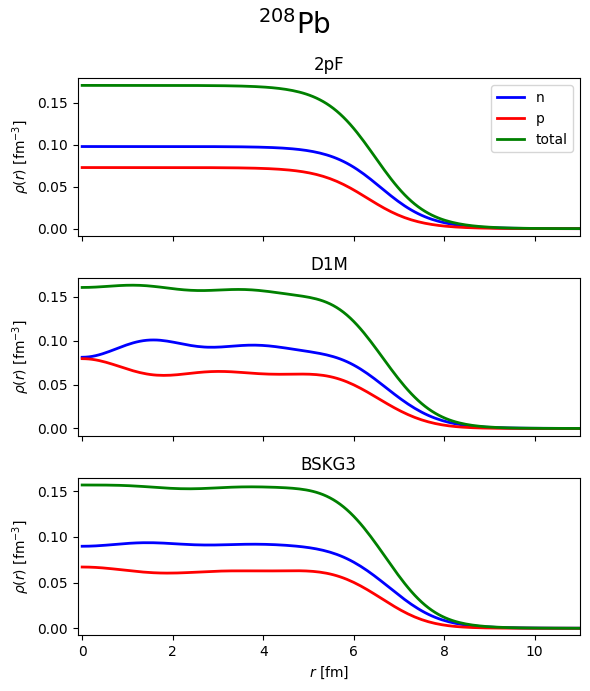

In [10]:
fig, axes = plt.subplots( 3, 1, figsize=(6, 7), sharex=True)
fig.suptitle(r"$^{208}$Pb", fontsize=20 )
plot_densities(axes[0], np.array(rho_p_2pf(R)), np.array(rho_n_2pf(R)), R)
plot_densities(axes[1], rho_p_d1m, rho_n_d1m, R)
plot_densities(axes[2], rho_p_bskg3, rho_n_bskg3, R)

axes[0].legend()
axes[2].set_xlabel(r"$r$ [fm]")

axes[0].set_ylabel(r"$\rho(r)$ [fm$^{-3}$]")
axes[1].set_ylabel(r"$\rho(r)$ [fm$^{-3}$]")
axes[2].set_ylabel(r"$\rho(r)$ [fm$^{-3}$]")

axes[0].set_title(r"2pF")
axes[1].set_title(r"D1M")
axes[2].set_title(r"BSKG3")

axes[0].set_xlim([-0.1,11])
plt.tight_layout()
plt.show()
